In [1]:
# Imports
# Importo las Bibliotecas que voy a usar en el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# DataSources
# Cargo la fuente de datos con la que voy a trabajar en el proyecto
df = pd.read_csv("data/ncr_ride_bookings.csv")

In [3]:
# Functions
# Definición de las funciones quevoy a usar en el proyecto.

def calcular_porcentaje_nulos(grupo):
    '''
    Devuelve el porcentaje de valores nulos en un grupo
    
    grupo: es la serie de pandas (una columna filtrada por un valor específico)
    grupo.isnull().sum(): cuántos valores nulos hay en el grupo
    len(grupo): cantidad total de registros en ese grupo
    '''
    return (grupo.isnull().sum() / len(grupo)) * 100


## Esquema del dataset

| Column Name | Description |
|:------------|:------------|
| Date | Date of the booking |
| Time | Time of the booking |
| Booking ID | Unique identifier for each ride booking |
| Booking Status | Status of booking (Completed, Cancelled by Customer, Cancelled by Driver, etc.) |
| Customer ID | Unique identifier for customers |
| Vehicle Type | Type of vehicle (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan) |
| Pickup Location | Starting location of the ride |
| Drop Location | Destination location of the ride |
| Avg VTAT | Average time for driver to reach pickup location (in minutes) |
| Avg CTAT | Average trip duration from pickup to destination (in minutes) |
| Cancelled Rides by Customer | Customer-initiated cancellation flag |
| Reason for cancelling by Customer | Reason for customer cancellation |
| Cancelled Rides by Driver | Driver-initiated cancellation flag |
| Driver Cancellation Reason | Reason for driver cancellation |
| Incomplete Rides | Incomplete ride flag |
| Incomplete Rides Reason | Reason for incomplete rides |
| Booking Value | Total fare amount for the ride |
| Ride Distance | Distance covered during the ride (in km) |
| Driver Ratings | Rating given to driver (1-5 scale) |
| Customer Rating | Rating given by customer (1-5 scale) |
| Payment Method | Method used for payment (UPI, Cash, Credit Card, Uber Wallet, Debit Card) 


# Exploración de datos (DEA)

**Objetivo:** investigar, visualizar y resumir el DataFrame antes de aplicar modelos o conclusiones definitivas.
        
```
Ejemplos
- df.head(), df.info(), df.describe()
- Detección de valores nulos (df.isnull().sum())
```

In [4]:
df.shape # El DataFrame tiene que tener al menos 50K registros y 10 columnaspara este TP

(150000, 21)

In [5]:
# veo la estructura del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [16]:
# Obtengo una muestra al azar del DataFrame
df.sample()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
44332,2024-01-18,20:23:08,"""CNR9563777""",Cancelled by Driver,"""CID9581219""",Premier Sedan,Okhla,Palam Vihar,3.7,NaN,...,NaN,1.0,The customer was coughing/sick,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.tail() # Sin argumentos, el método tail() me trae los últimos 5 elementos del DataFrame

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [8]:
df.isna()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,False,False,False,False,False,False,False,False,True,True,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
149996,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
149997,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
149998,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False


In [9]:
# Campos nulos (NaN)
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [20]:
# Por qué hay tantos valores nulos?
# Por qué la cantidad de valores nulos es redonda? (puede ser un DS sintético...)
datos_faltantes = df.isnull().sum()
porcentaje_faltantes = (datos_faltantes / len(df)) * 100
resumen = pd.DataFrame({
    'Columna': df.columns,
    'Cantidad_Faltante': datos_faltantes.values,
    'Porcentaje_Faltante': porcentaje_faltantes.values
})
resumen

,Columna,Cantidad_Faltante,Porcentaje_Faltante
0,Date,0,0.0
1,Time,0,0.0
2,Booking ID,0,0.0
3,Booking Status,0,0.0
4,Customer ID,0,0.0
5,Vehicle Type,0,0.0
6,Pickup Location,0,0.0
7,Drop Location,0,0.0
8,Avg VTAT,10500,7.0
9,Avg CTAT,48000,32.0


In [12]:
# 'Cancelled Rides by Customer' tiene un % muy alto de valores faltantes
# Hay un dato interesante que es el "Booking Status", este dato no es NaN en ningún registro
df['Booking Status'].unique().tolist()

['No Driver Found',
 'Incomplete',
 'Completed',
 'Cancelled by Driver',
 'Cancelled by Customer']

In [33]:
# Que pasa con las columnas que no tienen datos (NaN), según el tip ode "Booking Stauts"?

#key_columns = ['Booking Value','Avg VTAT', 'Avg CTAT','Cancelled Rides by Customer','Reason for cancelling by Customer','Cancelled Rides by Driver','Driver Cancellation Reason','Incomplete Rides','Incomplete Rides Reason','Ride Distance','Driver Ratings','Customer Rating','Payment Method']

# Pongo menos columnas, porque hay algunas que están relacionadas entre sí, como 'Cancelled Rides by Customer' y 'Reason for cancelling by Customer'"
key_columns = ['Booking Value','Avg VTAT', 'Avg CTAT','Cancelled Rides by Customer','Cancelled Rides by Driver','Incomplete Rides','Ride Distance','Driver Ratings','Customer Rating','Payment Method']

# Me fijo qué porcentaje de valores faltan en esas columnas que son NaN, según el vcalor (group_by) de 'Booking Status' para ver si hay algún patrón.
for col in key_columns:
    if col in df.columns:
        print(f"\n{col}:\n===============")
        nan_por_estado = df.groupby('Booking Status')[col].apply(calcular_porcentaje_nulos) # No entiendo por qué no tengo que pasarle el argumento del grupo a la función 'calcular_porcentaje_nulos' acá. Preguntar a Martín.
        # nan_por_estado es una serie de Pandas
        for status, pct in nan_por_estado.items():
            print(f"  {status:30s}: {pct}% faltantes")


Booking Value:
  Cancelled by Customer         : 100.0% faltantes
  Cancelled by Driver           : 100.0% faltantes
  Completed                     : 0.0% faltantes
  Incomplete                    : 0.0% faltantes
  No Driver Found               : 100.0% faltantes

Avg VTAT:
  Cancelled by Customer         : 0.0% faltantes
  Cancelled by Driver           : 0.0% faltantes
  Completed                     : 0.0% faltantes
  Incomplete                    : 0.0% faltantes
  No Driver Found               : 100.0% faltantes

Avg CTAT:
  Cancelled by Customer         : 100.0% faltantes
  Cancelled by Driver           : 100.0% faltantes
  Completed                     : 0.0% faltantes
  Incomplete                    : 0.0% faltantes
  No Driver Found               : 100.0% faltantes

Cancelled Rides by Customer:
  Cancelled by Customer         : 0.0% faltantes
  Cancelled by Driver           : 100.0% faltantes
  Completed                     : 100.0% faltantes
  Incomplete                    

In [25]:
# Puedo mostrar alguna correspondencia usando algún gráfico? (La IA me sugiere barras ,dispersión o mapa de calor. Voy con mapa de calor)

# Creo un diccionario vacío, para ir gardando lso resultados que voy a necusitor
resultados = {}

for col in key_columns:
    if col in df.columns:
        nan_por_estado = df.groupby('Booking Status')[col].apply(calcular_porcentaje_nulos)
        resultados[col] = nan_por_estado
        
df_heatmap = pd.DataFrame(resultados).T # Acá tuve que transponer los datos par que no falle el código... magia. Me falta dominar los dataframe

# Reordenar columnas para mejorar la visualización
orden_status = ['Completed', 'Cancelled by Customer', 'Cancelled by Driver', 'Incomplete', 'No Driver Found']
df_heatmap = df_heatmap[orden_status]


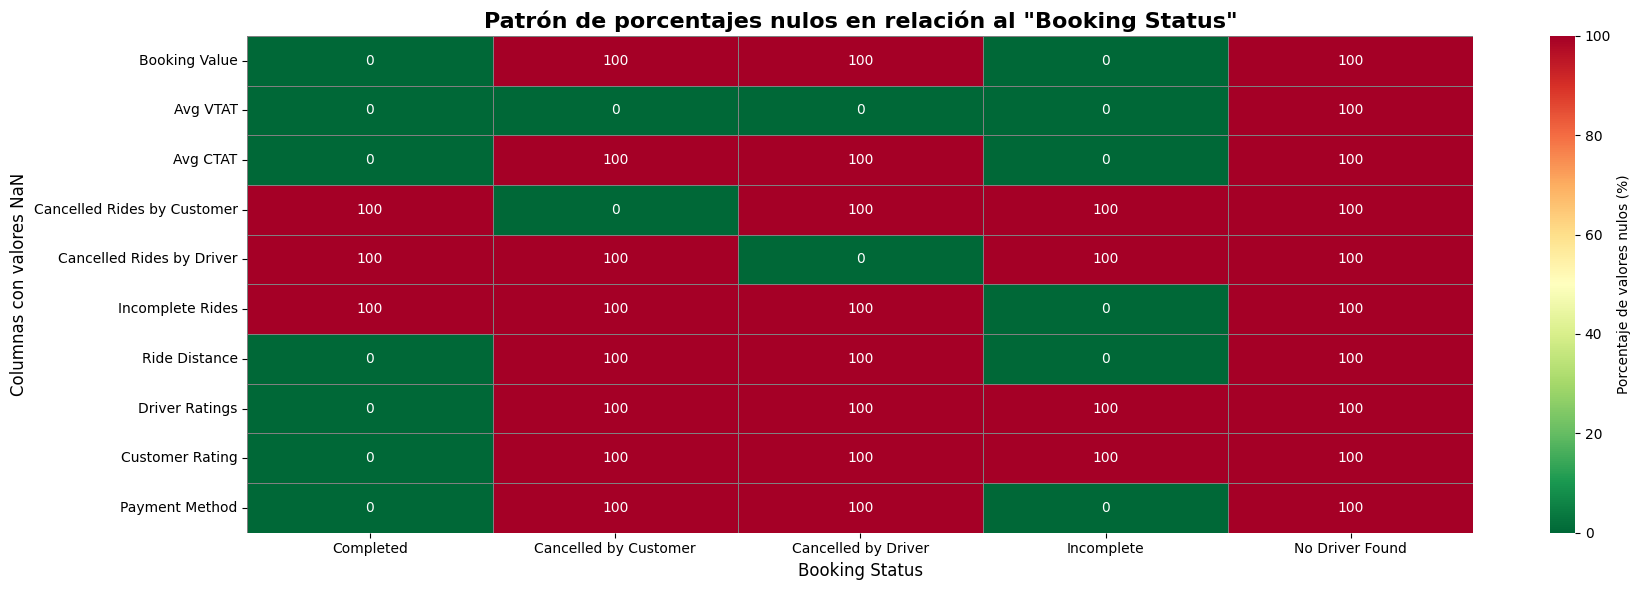

In [42]:
# Crear el heatmap
plt.figure(figsize=(18, 6))

sns.heatmap(df_heatmap, 
            annot=True,  # True: Muestra los valores | False: Esconde los valores
            fmt='.0f',   # Sin decimales
            cmap='RdYlGn_r',  # Rojo = muchos nulos, Verde = pocos nulos
            cbar_kws={'label': 'Porcentaje de valores nulos (%)'},
            linewidths=0.5,
            linecolor='gray')

#sns.heatmap(df_heatmap)
plt.title('Patrón de porcentajes nulos en relación al "Booking Status"', fontsize=16, fontweight='bold')
plt.xlabel('Booking Status', fontsize=12)
plt.ylabel('Columnas con valores NaN', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

## Conclusiones sobre los datos
**Sobre los datos nulos (NaN):**

Hay una relación directa entre los datos nulos y el estado de la reserva:
- Completed: Están todos los datos necesarios.
- Cancelled by Customer / Cancelled by Driver: tienen información parcial, porque el viaje no se realizó.
- Incomplete: tiene algo de data, pero no es el viaje entero
- No driver Found: no tiene data del viaje

**Conclusiones**
- Los datos que faltan (NaN) obedecen a un tema de diseño, no a un problema de carga de datos.
- Los datos que faltan (NaN) son información en sí mismos.